1. **Import** **Libraries**

In [32]:
# Import pandas for data handling
import pandas as pd

# Import numpy for numerical operations
import numpy as np

# Import visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns

# Import train-test split function
from sklearn.model_selection import train_test_split

# Import LabelEncoder for converting categorical data to numbers
from sklearn.preprocessing import LabelEncoder

# Import Random Forest model
from sklearn.ensemble import RandomForestClassifier

# Import evaluation metrics
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Import joblib to save and load model
import joblib

2. **Load** **Dataset**

In [33]:
# Read CSV file into dataframe
df=pd.read_csv('https://raw.githubusercontent.com/YBIFoundation/MLProjectIdeas/1285b62a60479f0cdf30fa80addde050f3da8b54/Transaction%20Fraud%20Detection%20for%20SafeBank.csv')

In [34]:
# Display first 5 rows of dataset
df.head

<bound method NDFrame.head of      CustomerID  TransactionAmount      TransactionTime   Location  \
0          1352            1834.26  2023-01-01 13:27:00  Bangalore   
1          1562            3130.03  2023-01-01 04:52:00    Chennai   
2          1828            3030.78  2023-01-01 13:17:00    Chennai   
3          1399             493.04  2023-01-01 21:05:00      Delhi   
4          1740            1298.36  2023-01-01 03:29:00    Chennai   
..          ...                ...                  ...        ...   
995        1342            4585.99  2023-01-02 08:31:00    Kolkata   
996        1960            1014.59  2023-01-01 07:04:00      Delhi   
997        1308            2500.03  2023-01-02 02:19:00     Mumbai   
998        1194            1804.07  2023-01-03 05:02:00  Hyderabad   
999        1322             908.05  2023-01-01 17:58:00    Chennai   

    TransactionType  AccountAgeMonths  BehaviorScore DeviceUsed  IsFraud  
0            Online                89           0.10     Mobile        0  
1               ATM                44           0.63     Tablet        0  
2     Bank Transfer                97           0.62     Tablet        1  
3               POS                13           0.24     Mobile        0  
4            Online                24           0.98    Desktop        0  
..              ...               ...            ...        ...      ...  
995   Bank Transfer                67           0.49     Mobile        0  
996             POS               117           0.88     Tablet        0  
997          Online                88           0.57     Mobile        0  
998          Online                53           0.66     Mobile        0  
999             POS                97           0.46     Mobile        0  

[1000 rows x 9 columns]>

3. **Data** ***Exploration***

In [35]:
# Check dataset shape (rows, columns)
print("Shape:", df.shape)

Shape: (1000, 9)


In [10]:
print(df.columns)

Index(['CustomerID', 'TransactionAmount', 'TransactionTime', 'Location',
       'TransactionType', 'AccountAgeMonths', 'BehaviorScore', 'DeviceUsed',
       'IsFraud'],
      dtype='object')


In [36]:
# Get dataset information (datatypes, null values)
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 9 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         1000 non-null   int64  
 1   TransactionAmount  1000 non-null   float64
 2   TransactionTime    1000 non-null   object 
 3   Location           1000 non-null   object 
 4   TransactionType    1000 non-null   object 
 5   AccountAgeMonths   1000 non-null   int64  
 6   BehaviorScore      1000 non-null   float64
 7   DeviceUsed         1000 non-null   object 
 8   IsFraud            1000 non-null   int64  
dtypes: float64(2), int64(3), object(4)
memory usage: 70.4+ KB


In [37]:
# Get statistical summary of numeric columns
df.describe

<bound method NDFrame.describe of      CustomerID  TransactionAmount      TransactionTime   Location  \
0          1352            1834.26  2023-01-01 13:27:00  Bangalore   
1          1562            3130.03  2023-01-01 04:52:00    Chennai   
2          1828            3030.78  2023-01-01 13:17:00    Chennai   
3          1399             493.04  2023-01-01 21:05:00      Delhi   
4          1740            1298.36  2023-01-01 03:29:00    Chennai   
..          ...                ...                  ...        ...   
995        1342            4585.99  2023-01-02 08:31:00    Kolkata   
996        1960            1014.59  2023-01-01 07:04:00      Delhi   
997        1308            2500.03  2023-01-02 02:19:00     Mumbai   
998        1194            1804.07  2023-01-03 05:02:00  Hyderabad   
999        1322             908.05  2023-01-01 17:58:00    Chennai   

    TransactionType  AccountAgeMonths  BehaviorScore DeviceUsed  IsFraud  
0            Online                89           0.10     Mobile        0  
1               ATM                44           0.63     Tablet        0  
2     Bank Transfer                97           0.62     Tablet        1  
3               POS                13           0.24     Mobile        0  
4            Online                24           0.98    Desktop        0  
..              ...               ...            ...        ...      ...  
995   Bank Transfer                67           0.49     Mobile        0  
996             POS               117           0.88     Tablet        0  
997          Online                88           0.57     Mobile        0  
998          Online                53           0.66     Mobile        0  
999             POS                97           0.46     Mobile        0  

[1000 rows x 9 columns]>

4. **Data** **Cleaning**

In [38]:
# Check missing values in each column
df.isnull().sum()

,0
CustomerID,0
TransactionAmount,0
TransactionTime,0
Location,0
TransactionType,0
AccountAgeMonths,0
BehaviorScore,0
DeviceUsed,0
IsFraud,0


In [8]:
df.columns

Index(['CustomerID', 'TransactionAmount', 'TransactionTime', 'Location',
       'TransactionType', 'AccountAgeMonths', 'BehaviorScore', 'DeviceUsed',
       'IsFraud'],
      dtype='object')

In [39]:
# Check distribution of target column (IsFraud)
df['IsFraud'].value_counts()

,count
IsFraud,
0,954
1,46


In [15]:
# Drop duplicates (if any)
df = df.drop_duplicates()

# Fill missing values (if any)
df = df.fillna(method='ffill')

/tmp/ipykernel_818/971755284.py:5: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method='ffill')


5. **Encode** **Categorical** **Variables**

In [40]:
# Create LabelEncoder object
le = LabelEncoder()

# Loop through all columns in dataset
for col in df.columns:

    # Check if column is categorical (object type)
    if df[col].dtype == 'object':

        # Convert categorical values into numeric values
        df[col] = le.fit_transform(df[col])

6. **Define** **Features** **and** **Target**

In [42]:
# Independent variables (input features)
X = df.drop('IsFraud', axis=1)

# Dependent variable (target output)
y = df['IsFraud']

7. **Train**-**Test** **Split**

In [ ]:
# Split dataset into training and testing sets
# 80% training, 20% testing
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,      # 20% test data
    random_state=42     # ensures reproducibility
)

8. **Train** **Random** **Forest** **Model**

In [ ]:
# Create Random Forest model
model = RandomForestClassifier(
    n_estimators=100,   # number of trees
    random_state=42     # reproducibility
)

# Train model using training data
model.fit(X_train, y_train)

9. **Model** **Prediction**

In [ ]:
# Predict target values for test data
y_pred = model.predict(X_test)

10. **Model** **Evaluation**

In [43]:
# Calculate accuracy score
print("Accuracy:", accuracy_score(y_test, y_pred))

# Display detailed classification report
print("\nClassification Report:\n", classification_report(y_test, y_pred))

Accuracy: 0.945

Classification Report:
               precision    recall  f1-score   support

           0       0.94      1.00      0.97       189
           1       0.00      0.00      0.00        11

    accuracy                           0.94       200
   macro avg       0.47      0.50      0.49       200
weighted avg       0.89      0.94      0.92       200



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


11. **Confusion** **Matrix**

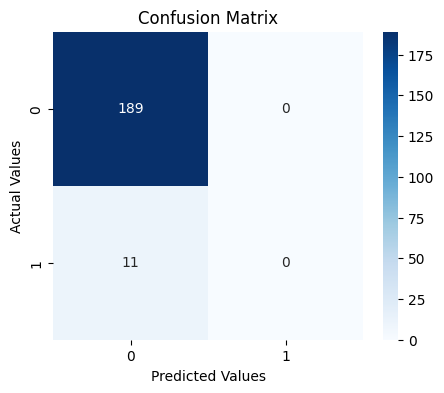

In [44]:
# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Set figure size for plot
plt.figure(figsize=(5,4))

# Create heatmap for confusion matrix
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

# Add title and labels
plt.title("Confusion Matrix")
plt.xlabel("Predicted Values")
plt.ylabel("Actual Values")

# Show plot
plt.show()

12. **Feature** **Importance**

In [45]:
# Create dataframe of feature importance values
importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
})

# Sort features by importance (descending order)
importance = importance.sort_values(by='Importance', ascending=False)

# Display feature importance table
importance

,Feature,Importance
2,TransactionTime,0.195312
0,CustomerID,0.185089
1,TransactionAmount,0.170376
6,BehaviorScore,0.144230
5,AccountAgeMonths,0.143448
3,Location,0.071246
4,TransactionType,0.047712
7,DeviceUsed,0.042587


13. **Feature** **Importance** **Visualization**

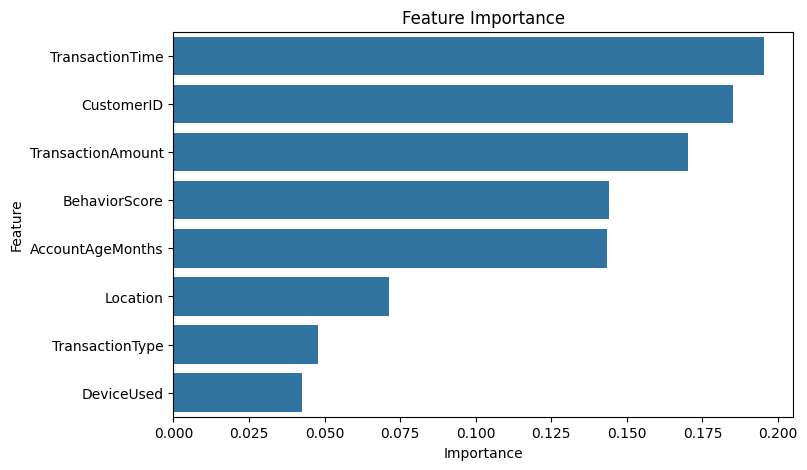

In [46]:
# Set figure size
plt.figure(figsize=(8,5))

# Plot bar chart of feature importance
sns.barplot(x='Importance', y='Feature', data=importance)

# Add title
plt.title("Feature Importance")

# Show plot
plt.show()

14. **Sample** **Prediction**

In [47]:
# Take one sample from test dataset
sample = X_test.iloc[0].values.reshape(1, -1)

# Predict fraud or not fraud
print("Prediction:", model.predict(sample))

Prediction: [0]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


5. **Save** **Model**

In [48]:
# Save trained model to file
joblib.dump(model, "SafeBank_Fraud_Model.pkl")

['SafeBank_Fraud_Model.pkl']

16. **Load** **Saved** **Model**

In [49]:
# Load saved model from file
loaded_model = joblib.load("SafeBank_Fraud_Model.pkl")

17. **Test** **Loaded** **Model**

In [ ]:
# Use loaded model to predict sample data
loaded_model.predict(X_test.iloc[0].values.reshape(1, -1))